# NeuroSegment-BraTS: Análise Descritiva e Desbalanceamento de Dados

**Notebook 2:** Limpeza, Refinamento e Análise Exploratória (EDA).

Conforme os requisitos do projeto, esta etapa visa compreender a distribuição espacial das classes de tecido nas imagens médicas. Nosso objetivo é investigar o nível de **desbalanceamento da variável-alvo** (as classes do tumor) em relação ao fundo e ao tecido cerebral saudável.

## 1. Bibliotecas

In [9]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import pandas as pd

# Caminho relativo apontando para a pasta raw
DATA_PATH = '../data/raw/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData'

## 2. Refinamento dos Dados: O Problema do Fundo Estrutural

Antes de utilizar os dados ma rede neural, precisamos avaliar ruídos e possíveis problemas estruturais na imagem.
Uma grande dificuldades que entramos com imagens médicas é uma limitação física, especialmente em ressonâncias magnéticas (MRI), por conta da imensa quantidade de espaço vazio (fundo/background) ao redor do crânio. Esse espaço não tem nenhuma informação clínica, mas consome memória da GPU durante o treinamento.

O código abaixo extrai uma fatia e evidencia a "caixa delimitadora" (Bounding Box) do cérebro real, provando a necessidade da técnica de **CropForeground** que implementaremos na etapa de Adaptação dos Dados.

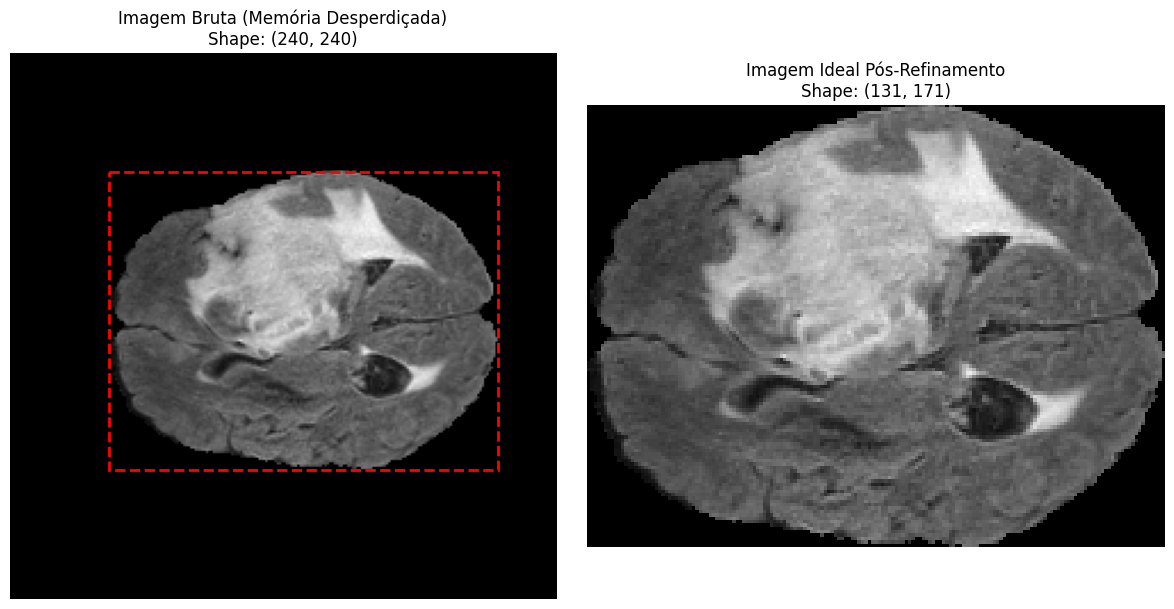

Área Original (Pixels): 57600
Área Útil do Cérebro: 22401


In [10]:
# 1. Caminho e Paciente
DATA_PATH = '../data/raw/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData'
patient_folders = sorted(glob.glob(os.path.join(DATA_PATH, "BraTS20_Training_*")))
sample_patient = patient_folders[0]
patient_id = os.path.basename(sample_patient)

# 2. Carregando a modalidade FLAIR
path_flair = os.path.join(sample_patient, f"{patient_id}_flair.nii")
vol_flair = nib.load(path_flair).get_fdata()

# 3. Escolhendo a fatia
slice_idx = 75
img_slice = vol_flair[:, :, slice_idx]

# 4. Encontrando a Bounding Box real do cérebro (onde o pixel não é preto/zero)
non_zero_coords = np.argwhere(img_slice > 0)
(y_start, x_start), (y_end, x_end) = non_zero_coords.min(0), non_zero_coords.max(0) + 1

# 5. Plotando a prova
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Imagem 1: O problema (A imagem inteira carregada na memória)
ax1.imshow(img_slice, cmap='gray')
ax1.set_title(f'Imagem Bruta (Memória Desperdiçada)\nShape: {img_slice.shape}', fontsize=12)
ax1.axis('off')

# Desenhando o retângulo vermelho onde realmente importa
rect = patches.Rectangle((x_start, y_start), x_end - x_start, y_end - y_start, 
                         linewidth=2, edgecolor='r', facecolor='none', linestyle='--')
ax1.add_patch(rect)

# Imagem 2: A solução (A imagem recortada que a IA deveria ver)
cropped_slice = img_slice[y_start:y_end, x_start:x_end]
ax2.imshow(cropped_slice, cmap='gray')
ax2.set_title(f'Imagem Ideal Pós-Refinamento\nShape: {cropped_slice.shape}', fontsize=12)
ax2.axis('off')

plt.tight_layout()
plt.show()

area_original = img_slice.shape[0] * img_slice.shape[1]
area_cortada = cropped_slice.shape[0] * cropped_slice.shape[1]

print(f"Área Original (Pixels): {area_original}")
print(f"Área Útil do Cérebro: {area_cortada}")